# Core Factorial: Selective Interference Effect

> Simulate the interference × retrieval mode factorial to demonstrate graded vulnerability.

The selective interference effect predicts that a visuospatial task after a
film or reminder impairs involuntary recall more than voluntary recall, while
recognition is completely spared.

This notebook sweeps interference MCF binding strength under three retrieval
modes — involuntary (no retrieval control), voluntary (start-drift +
sharpened competition), and recognition (item-to-context pathway, immune by
architecture) — to show that the gradient emerges from a single memory
system operating at different control settings.

All simulations use `shared_support=0.0` so that retrieval depends entirely
on context-dependent learned associations.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from jax import random
import os

from jaxcmr.analyses.spc import fixed_pres_spc
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
from jaxcmr.selective_interference import (
    Paradigm,
    add_filler_boundary,
    compute_n_presented,
    film_recalled_stats,
    light_to_dark_colors,
    load_or_fit_params,
    make_factory,
    make_is_emotional,
    plot_interference_spc,
    plot_summary_dv,
    prepare_sweep,
    run_sweep,
    standard_remap,
)

warnings.filterwarnings("ignore")

In [2]:
# --- paradigm geometry ---
N_FILM = 16
N_BREAK = 16
N_INTERFERENCE = 16
N_FILLER = 16
N_BREAK_MAX = 32
N_INTERFERENCE_MAX = 32
N_FILLER_MAX = 32
EXPERIMENT_COUNT = 100

# --- interference sweep ---
MCF_VALUES = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0]

# --- retrieval modes ---
# Involuntary: no retrieval control (context stays post-interference)
INVOLUNTARY = {"start_drift_scale": 0.01, "tau_scale": 1.0}
# Voluntary: strong reinstatement + sharpened competition
VOLUNTARY = {"start_drift_scale": 2.0, "tau_scale": 2.0}

# --- encoding scales (held fixed) ---
ENCODING_SCALES = {"interference_drift_scale": 0.5}

# --- pre-cache scales ---
PRE_CACHE_SCALES = {
    "break_drift_scale": 1.0,
    "break_mcf_scale": 1.0,
    "reminder_start_drift_scale": 4.0,
    "reminder_drift_scale": 0.3,
}

# --- fitting ---
SEED = 0
DATA_TAG = "HealeyKahana2014"
DATA_PATH = "data/HealeyKahana2014.h5"
TRIAL_QUERY = "data['listtype'] == -1"
MODEL_NAME = "WeirdCMRPosStop"
BEST_OF = 3
RUN_TAG = "fixed_term_best_of_3"
REDO_FITS = False
PARAM_SCALES = {"stop_probability_scale": 0.4, "shared_support": 0.0}
FIT_DIR = "projects/selective_interference/simulations/fits"
FIGURE_DIR = "projects/selective_interference/simulations/figures"
FIGURE_STR = "core_factorial"

In [3]:
paradigm = Paradigm(
    n_film=N_FILM,
    n_break=N_BREAK,
    n_interference=N_INTERFERENCE,
    n_filler=N_FILLER,
    n_break_max=N_BREAK_MAX,
    n_interference_max=N_INTERFERENCE_MAX,
    n_filler_max=N_FILLER_MAX,
    experiment_count=EXPERIMENT_COUNT,
)

project_root = Path(find_project_root())
fit_path = project_root / FIT_DIR / f"{DATA_TAG}_{MODEL_NAME}_{RUN_TAG}.json"

data = load_data(str(project_root / DATA_PATH))
trial_mask = generate_trial_mask(data, TRIAL_QUERY)
is_emotional = make_is_emotional(paradigm, False, False)
factory = make_factory(is_emotional=is_emotional)
rng = random.PRNGKey(SEED)

params, n_subjects = load_or_fit_params(
    fit_path,
    param_scales=PARAM_SCALES,
    data=data,
    trial_mask=trial_mask,
    model_factory=factory,
    redo_fits=REDO_FITS,
    best_of=BEST_OF,
)

prep = prepare_sweep(
    params, paradigm, factory,
    cache_after="reminder", tier="standard",
    **PRE_CACHE_SCALES,
)
print(f"{n_subjects} subjects, shared_support=0")

Loaded fits from /Users/jordangunn/jaxcmr/projects/selective_interference/simulations/fits/HealeyKahana2014_WeirdCMRPosStop_fixed_term_best_of_3.json
  Scaled stop_probability_scale by 0.4
  Scaled shared_support by 0.0


126 subjects, shared_support=0


In [4]:
mcf_values = np.array(MCF_VALUES)
n_presented = compute_n_presented(
    paradigm, show_break=True, show_fillers=False,
)

# --- Involuntary: no retrieval control ---
recalls_inv, rng = run_sweep(
    prep, rng,
    interference_mcf_scale=mcf_values,
    **ENCODING_SCALES,
    **INVOLUNTARY,
)

# --- Voluntary: strong retrieval control ---
recalls_vol, rng = run_sweep(
    prep, rng,
    interference_mcf_scale=mcf_values,
    **ENCODING_SCALES,
    **VOLUNTARY,
)

# --- Compute SPCs + stats for each mode ---
def _process(recalls_4d):
    spcs, means, ci_los, ci_his = [], [], [], []
    for i in range(recalls_4d.shape[0]):
        recalls = recalls_4d[i].reshape(-1, recalls_4d.shape[-1])
        recalls = standard_remap(recalls, paradigm)
        spcs.append(fixed_pres_spc(recalls, n_presented))
        m, lo, hi = film_recalled_stats(recalls, paradigm, n_subjects)
        means.append(m)
        ci_los.append(lo)
        ci_his.append(hi)
    return spcs, means, ci_los, ci_his

inv_spcs, inv_means, inv_lo, inv_hi = _process(recalls_inv)
vol_spcs, vol_means, vol_lo, vol_hi = _process(recalls_vol)

labels = [f"{v:.2f}" for v in mcf_values]
colors = light_to_dark_colors(len(mcf_values))

print(f"Involuntary: mcf=0 → {inv_means[0]:.1f}, mcf=2 → {inv_means[-1]:.1f}, effect={inv_means[0]-inv_means[-1]:+.1f}")
print(f"Voluntary:   mcf=0 → {vol_means[0]:.1f}, mcf=2 → {vol_means[-1]:.1f}, effect={vol_means[0]-vol_means[-1]:+.1f}")

Involuntary: mcf=0 → 0.1, mcf=2 → 0.0, effect=+0.1
Voluntary:   mcf=0 → 2.0, mcf=2 → 1.4, effect=+0.6


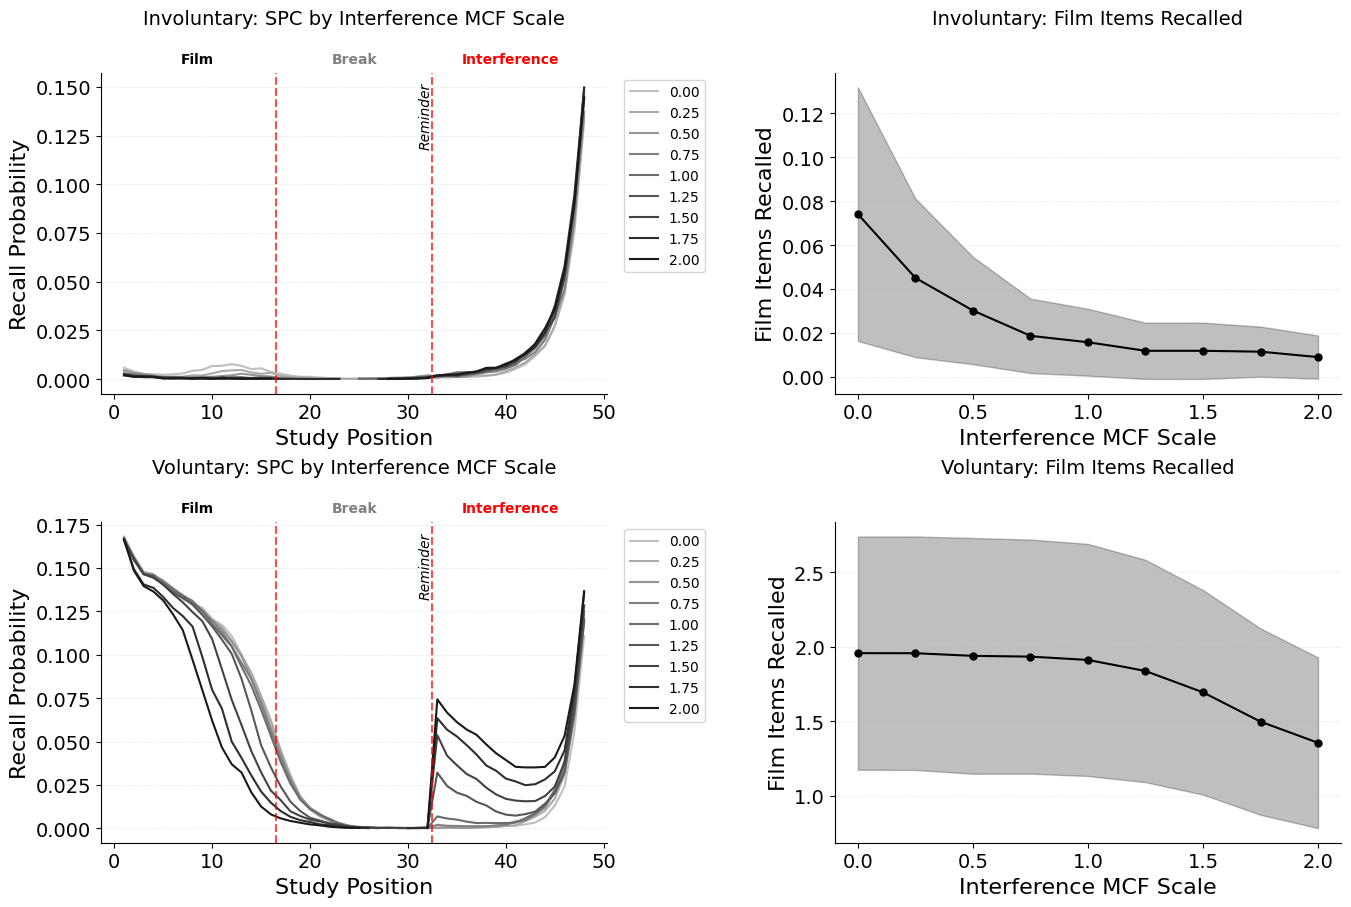

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), gridspec_kw={"wspace": 0.45, "hspace": 0.4})

# --- Top row: Involuntary ---
plot_interference_spc(
    inv_spcs, labels, n_film=N_FILM, n_break=N_BREAK,
    n_presented=n_presented, color_cycle=colors, axis=axes[0, 0],
)
axes[0, 0].set_title("Involuntary: SPC by Interference MCF Scale", fontsize=14, pad=35)
axes[0, 0].legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=10)

plot_summary_dv(
    mcf_values.tolist(), inv_means, inv_lo, inv_hi,
    xlabel="Interference MCF Scale", axis=axes[0, 1],
)
axes[0, 1].set_title("Involuntary: Film Items Recalled", fontsize=14, pad=35)

# --- Bottom row: Voluntary ---
plot_interference_spc(
    vol_spcs, labels, n_film=N_FILM, n_break=N_BREAK,
    n_presented=n_presented, color_cycle=colors, axis=axes[1, 0],
)
axes[1, 0].set_title("Voluntary: SPC by Interference MCF Scale", fontsize=14, pad=35)
axes[1, 0].legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=10)

plot_summary_dv(
    mcf_values.tolist(), vol_means, vol_lo, vol_hi,
    xlabel="Interference MCF Scale", axis=axes[1, 1],
)
axes[1, 1].set_title("Voluntary: Film Items Recalled", fontsize=14, pad=35)

plt.tight_layout()

if FIGURE_DIR and FIGURE_STR:
    os.makedirs(FIGURE_DIR, exist_ok=True)
    base = os.path.join(FIGURE_DIR, FIGURE_STR)
    plt.savefig(f"{base}.png", bbox_inches="tight", dpi=600)
    plt.savefig(f"{base}.svg", bbox_inches="tight")
plt.show()